# 信号强度 ×2 时，peak 分布统计量是否也 ×2？（工作名 `peak_distribution`）

## 问题

> 固定环境噪声，把信号强度加倍：peak 分布的**众数 / 中位数 / 均值 / p90** 会不会也加倍？
> **PoD50 / PoD90 的位置**（使检测概率达 50% / 90% 的信号能量）附近，上述量又如何缩放？

## 名词

- **peak**：信号窗内宏像元直方图的最大 bin 计数。
- **boost**：信号强度倍率；单脉冲能量 = `boost × E_PULSE_BASE`（799.4 nJ）。
- **noise**：宏像元每 1 ns bin 的平均累加计数（与 `PoD_esti` 一致）。
- **PoD**（Probability of Detection，检测概率）= $P(\text{peak} \ge T)$，
  $T$ 取自 `PoD_esti_v05` 的 FAR（False Alarm Rate，虚警率）阈值。
- **PoD50 / PoD90 位置**：使 PoD = 50% / 90% 的信号能量（boost）。
- **二值硬上限** $n_{tr} = 27\times N_{\text{shots}}$：peak 不可能超过它。

## 数据

`peak_distribution_v01_cache.npz`（由 `peak_distribution_scan.py` 生成）：
N_shots = 1 与 4；每档若干代表 noise；boost 对数网格（含大量 `(b, 2b)` 对）；每点 8000 条 MC。

```powershell
$env:PYTHONIOENCODING="utf-8"
python peak_distribution_scan.py
python build_peak_distribution.py
```

In [1]:
import os
os.environ["POD_CORE_QUIET"] = "1"
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# 中文字体：本 notebook 只读缓存、不 import pod_esti_v05_core，
# 必须自己设，否则中文全部变成方框。
for _f in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC"]:
    try:
        matplotlib.rcParams["font.sans-serif"] = [_f]
        break
    except Exception:
        continue
matplotlib.rcParams["axes.unicode_minus"] = False

CACHE = "peak_distribution_v01_cache.npz"
if not os.path.exists(CACHE):
    raise FileNotFoundError(f"缺少 {CACHE}，请先：python peak_distribution_scan.py")

_z = np.load(CACHE, allow_pickle=True)
BOOSTS = np.asarray(_z["boosts"], float)
N_MC = int(_z["n_mc"])
FAR_TAGS = [str(t) for t in _z["far_tags"]]
POD_FAR_TAGS = [str(t) for t in _z["pod_far_tags"]]
E_BASE = float(_z["e_pulse_base"])
E_NJ = BOOSTS * E_BASE * 1e9
N_LIST = [1, 4]

DATA = {}
for n in N_LIST:
    DATA[n] = {
        "noise": np.asarray(_z[f"noise_{n}"], float),
        "cnt": np.asarray(_z[f"cnt_{n}"]),          # (n_boost, n_noise, n_tr+2)
        "done": np.asarray(_z[f"done_{n}"], bool),
        "T": np.asarray(_z[f"T_{n}"]),              # (n_far, n_noise)
        "n_tr": 27 * n,
    }
    if not DATA[n]["done"].all():
        print(f"⚠ N={n}：{(~DATA[n]['done']).sum()} 档未完成")


def bc_mean_std(cnt):
    v = np.arange(cnt.shape[-1], dtype=float)
    n = np.where(cnt.sum(-1) == 0, np.nan, cnt.sum(-1).astype(float))
    mean = (cnt * v).sum(-1) / n
    m2 = (cnt * v * v).sum(-1) / n
    return mean, np.sqrt(np.maximum(m2 - mean**2, 0.0))


def bc_quantile(cnt, q):
    c = np.asarray(cnt, float)
    tot = c.sum()
    if tot <= 0:
        return np.nan
    cdf = np.cumsum(c) / tot
    i = min(int(np.searchsorted(cdf, q)), c.size - 1)
    lo = cdf[i - 1] if i > 0 else 0.0
    frac = (q - lo) / max(cdf[i] - lo, 1e-12)
    return i - 0.5 + float(np.clip(frac, 0.0, 1.0))


def bc_mode(cnt):
    '''众数 = 概率质量最大的 peak 取值。'''
    c = np.asarray(cnt)
    if c.sum() <= 0:
        return np.nan
    return float(np.argmax(c))


def bc_pmf(cnt):
    c = np.asarray(cnt, float)
    return c / max(c.sum(), 1.0)


def bc_pod(cnt, T):
    '''PoD = P(peak ≥ T)。'''
    c = np.asarray(cnt, float)
    tot = c.sum()
    if tot <= 0:
        return np.nan
    v = np.arange(c.size)
    return float(c[v >= T].sum() / tot)


def crossing_boost(boosts, pod, level):
    '''在 log10(boost) 上插值找 PoD 跨越 level 的位置；越界返回 nan。'''
    boosts = np.asarray(boosts, float)
    pod = np.asarray(pod, float)
    # 跳过 boost=0
    m = boosts > 0
    b, p = boosts[m], pod[m]
    if len(b) < 2:
        return np.nan
    # 保序
    p = np.maximum.accumulate(p)
    if p[0] >= level:
        return float(b[0])
    if p[-1] < level:
        return np.nan
    i = int(np.searchsorted(p, level))
    x0, x1 = np.log10(b[i - 1]), np.log10(b[i])
    t = (level - p[i - 1]) / max(p[i] - p[i - 1], 1e-12)
    return float(10 ** (x0 + t * (x1 - x0)))


# 预计算统计量：(n_boost, n_noise)
STAT = {}
for n in N_LIST:
    mean, std = bc_mean_std(DATA[n]["cnt"])
    nb, ng = mean.shape
    med = np.zeros_like(mean)
    mode = np.zeros_like(mean)
    p90 = np.zeros_like(mean)
    for i in range(nb):
        for j in range(ng):
            med[i, j] = bc_quantile(DATA[n]["cnt"][i, j], 0.50)
            mode[i, j] = bc_mode(DATA[n]["cnt"][i, j])
            p90[i, j] = bc_quantile(DATA[n]["cnt"][i, j], 0.90)
    STAT[n] = {"mean": mean, "std": std, "median": med, "mode": mode, "p90": p90}

# 找 (b, 2b) 对：对每个 boost[i]>0，找最接近 2*boost[i] 的网格点
PAIR_IDX = []   # list of (i_lo, i_hi)，要求 |boost[hi]/boost[lo] - 2| < 5%
for i, b in enumerate(BOOSTS):
    if b <= 0:
        continue
    target = 2.0 * b
    j = int(np.argmin(np.abs(BOOSTS - target)))
    if BOOSTS[j] <= b:
        continue
    if abs(BOOSTS[j] / b - 2.0) / 2.0 < 0.05:   # 相对误差 < 5%
        PAIR_IDX.append((i, j))
# 去重（同一 hi 只保留一个）
_seen = set()
_pairs = []
for i, j in PAIR_IDX:
    if j not in _seen:
        _seen.add(j)
        _pairs.append((i, j))
PAIR_IDX = _pairs

print(f"缓存：每点 {N_MC:,} 条 MC；boost 共 {len(BOOSTS)} 档；"
      f"(b,≈2b) 对 {len(PAIR_IDX)} 组")
print(f"E_PULSE_BASE = {E_BASE*1e9:.2f} nJ")
for n in N_LIST:
    print(f"N={n}: noise = {list(DATA[n]['noise'])}，硬上限 n_tr = {DATA[n]['n_tr']}")
print("缩放对比用的 boost 对（E_lo → E_hi ≈ ×2）：")
for i, j in PAIR_IDX:
    print(f"  {E_NJ[i]:7.3f} nJ → {E_NJ[j]:7.3f} nJ  "
          f"（实际倍率 {BOOSTS[j]/BOOSTS[i]:.3f}）")

缓存：每点 8,000 条 MC；boost 共 26 档；(b,≈2b) 对 21 组
E_PULSE_BASE = 799.44 nJ
N=1: noise = [np.float64(0.5), np.float64(2.0), np.float64(5.0), np.float64(8.0)]，硬上限 n_tr = 27
N=4: noise = [np.float64(1.0), np.float64(5.0), np.float64(15.0), np.float64(30.0)]，硬上限 n_tr = 108
缩放对比用的 boost 对（E_lo → E_hi ≈ ×2）：
    0.799 nJ →   1.660 nJ  （实际倍率 2.076）
    0.959 nJ →   1.992 nJ  （实际倍率 2.077）
    1.152 nJ →   2.391 nJ  （实际倍率 2.076）
    1.382 nJ →   2.870 nJ  （实际倍率 2.076）
    1.660 nJ →   3.445 nJ  （实际倍率 2.076）
    1.992 nJ →   4.135 nJ  （实际倍率 2.075）
    2.391 nJ →   4.963 nJ  （实际倍率 2.076）
    2.870 nJ →   5.957 nJ  （实际倍率 2.076）
    3.445 nJ →   7.150 nJ  （实际倍率 2.076）
    4.135 nJ →   8.583 nJ  （实际倍率 2.076）
    4.963 nJ →  10.302 nJ  （实际倍率 2.076）
    5.957 nJ →  12.366 nJ  （实际倍率 2.076）
    7.150 nJ →  14.842 nJ  （实际倍率 2.076）
    8.583 nJ →  17.816 nJ  （实际倍率 2.076）
   10.302 nJ →  21.385 nJ  （实际倍率 2.076）
   12.366 nJ →  25.668 nJ  （实际倍率 2.076）
   14.842 nJ →  30.811 nJ  （实际倍率 2.076）
   17.816 nJ →  36.98

## 模块 1：peak 概率分布 — 信号 vs 信号×2 直接对照

每个子图固定一个 noise，画若干组 `(E, 2E)` 的 peak 概率质量分布。
若线性缩放成立，×2 曲线应是 ×1 曲线在横轴上**整体拉长一倍**（且 bump 移到约 2 倍位置）。

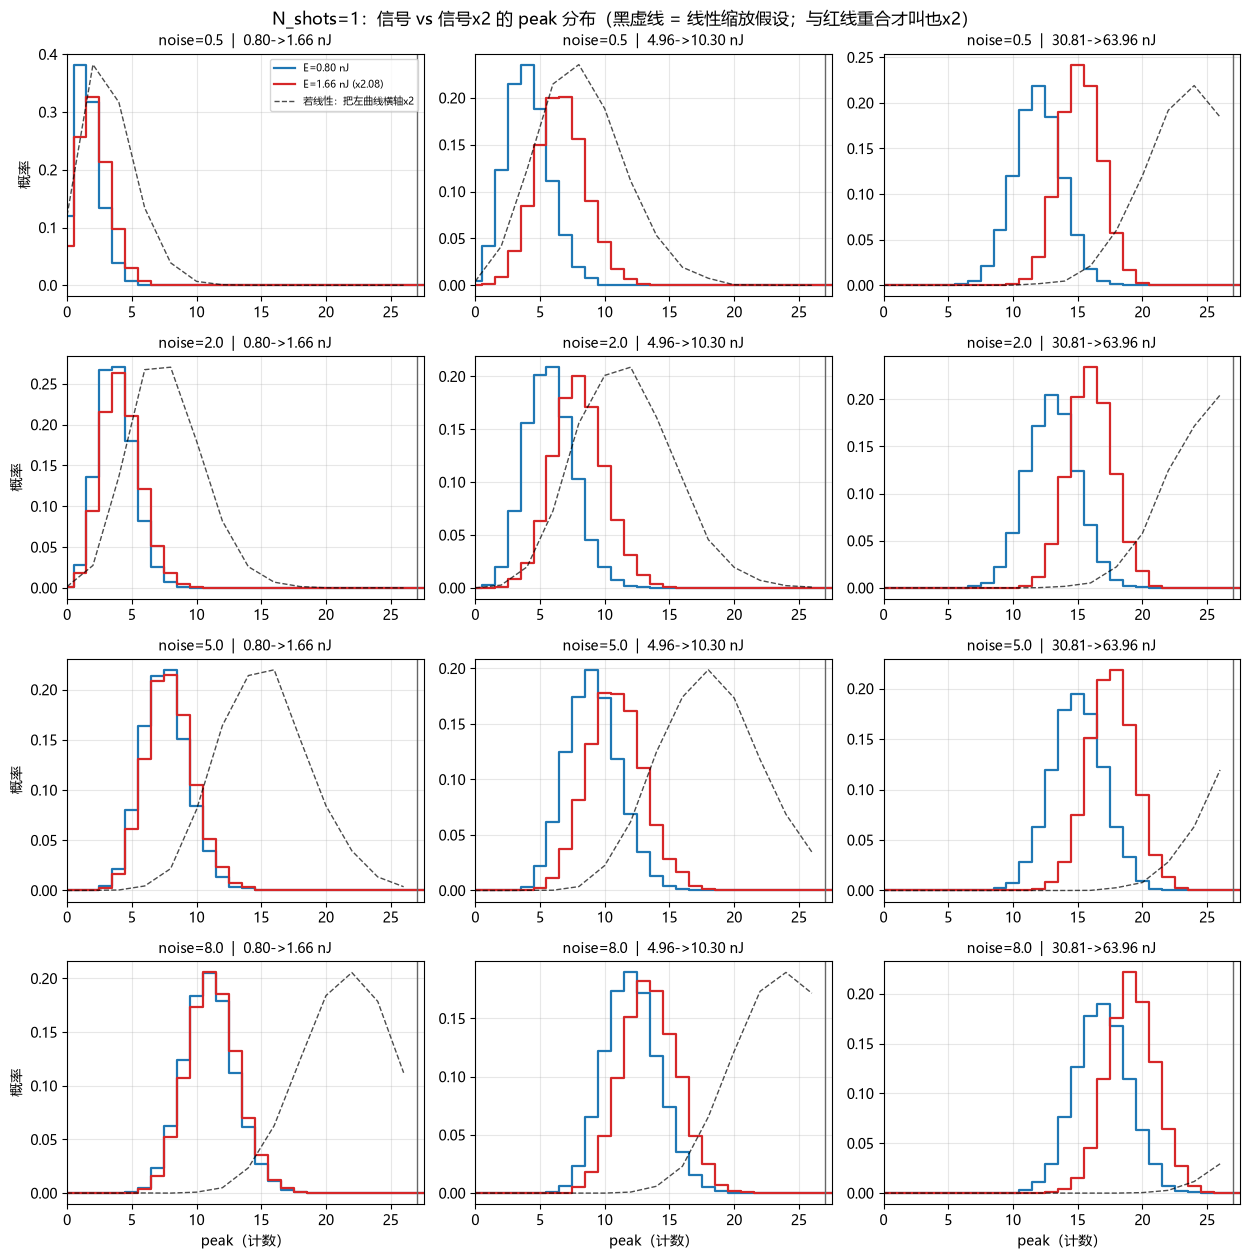

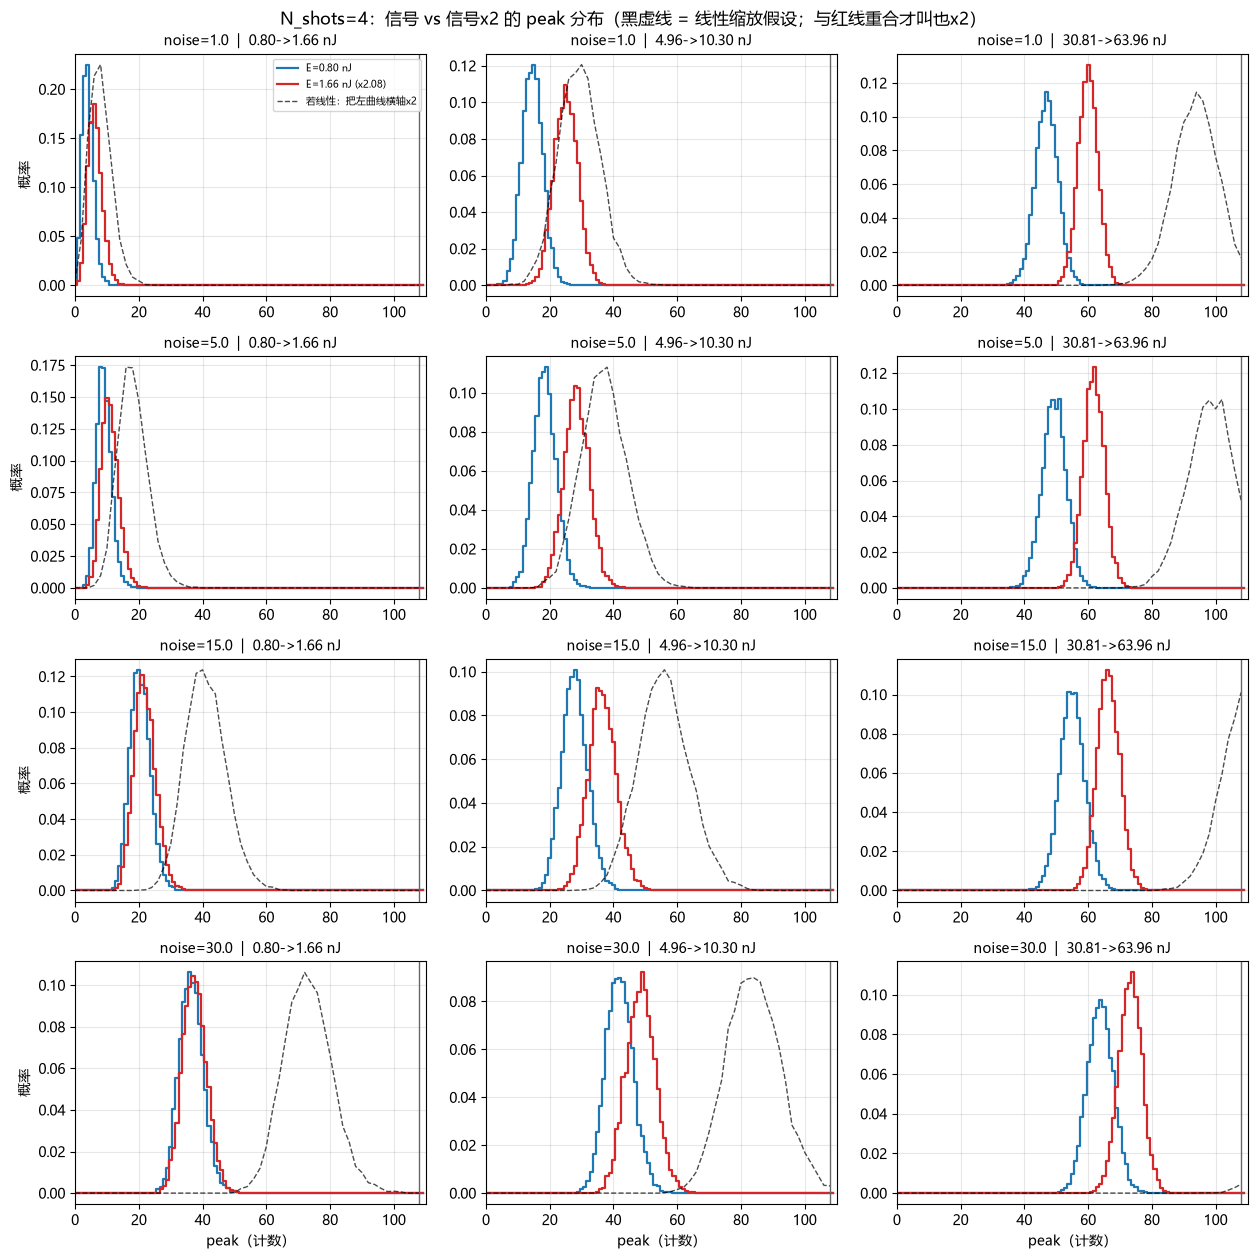

In [2]:
# 挑 3 组有代表性的 (b, 2b) 对：弱 / 中 / 强
_pick_pairs = []
if PAIR_IDX:
    mid = len(PAIR_IDX) // 2
    for k in sorted({0, mid, len(PAIR_IDX) - 1}):
        _pick_pairs.append(PAIR_IDX[k])

for n in N_LIST:
    d = DATA[n]
    noises = d["noise"]
    # 每个 N 画全部 noise 档（最多 4）
    fig, axes = plt.subplots(len(noises), len(_pick_pairs),
                             figsize=(4.2 * len(_pick_pairs), 3.2 * len(noises)),
                             sharex=False, sharey=False, squeeze=False)
    for row, jn in enumerate(range(len(noises))):
        for col, (i, j) in enumerate(_pick_pairs):
            ax = axes[row, col]
            v = np.arange(d["cnt"].shape[-1])
            ax.step(v, bc_pmf(d["cnt"][i, jn]), where="mid", color="C0", lw=1.6,
                    label=f"E={E_NJ[i]:.2f} nJ")
            ax.step(v, bc_pmf(d["cnt"][j, jn]), where="mid", color="C3", lw=1.6,
                    label=f"E={E_NJ[j]:.2f} nJ (x{BOOSTS[j]/BOOSTS[i]:.2f})")
            # 若线性：把弱信号分布的横轴 x2 叠上去（虚线）
            pmf_lo = bc_pmf(d["cnt"][i, jn])
            v2 = v * 2.0
            m = v2 <= d["n_tr"]
            ax.plot(v2[m], pmf_lo[m], "k--", lw=1.0, alpha=0.7,
                    label="若线性：把左曲线横轴x2")
            ax.axvline(d["n_tr"], color="0.4", lw=1.0)
            ax.set_xlim(0, d["n_tr"] * 1.02)
            ax.set_title(f"noise={noises[jn]:.1f}  |  "
                         f"{E_NJ[i]:.2f}->{E_NJ[j]:.2f} nJ", fontsize=10)
            ax.grid(alpha=0.3)
            if row == len(noises) - 1:
                ax.set_xlabel("peak（计数）")
            if col == 0:
                ax.set_ylabel("概率")
            if row == 0 and col == 0:
                ax.legend(fontsize=7.5, loc="upper right")
    fig.suptitle(f"N_shots={n}：信号 vs 信号x2 的 peak 分布"
                 f"（黑虚线 = 线性缩放假设；与红线重合才叫也x2）",
                 fontsize=12)
    fig.tight_layout()
    plt.show()

## 模块 2：缩放比 = 统计量(2E) / 统计量(E)  （再除以实际能量倍率）

网格上相邻「加倍」对的实际倍率 ≈ 2.08（对数步长所致），不是精确的 2。
因此画的是**归一化缩放比**：

$$\text{norm\_ratio} = \frac{\mathrm{stat}(E_{\mathrm{hi}})/\mathrm{stat}(E_{\mathrm{lo}})}{E_{\mathrm{hi}}/E_{\mathrm{lo}}}$$

线性成立 ⇔ norm_ratio = **1**（图中水平虚线）。
stat ∈ {众数 mode，中位数 median，均值 mean，p90}。

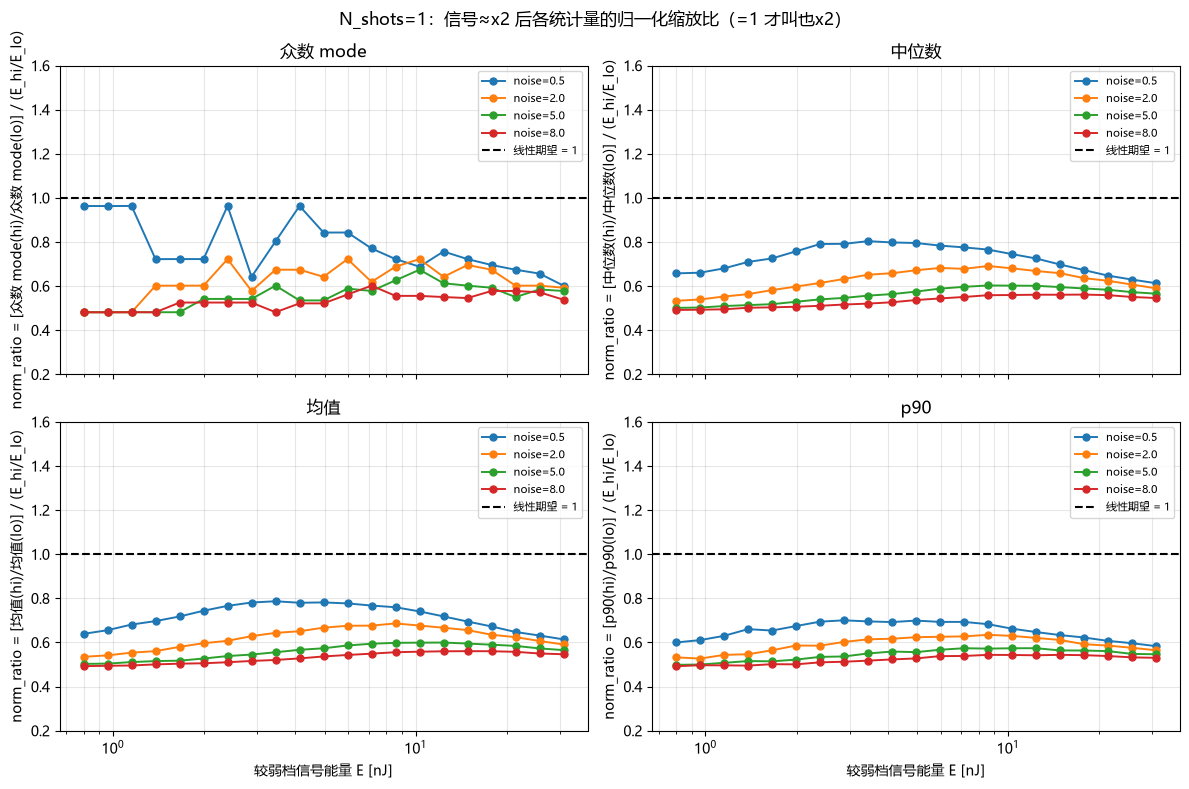

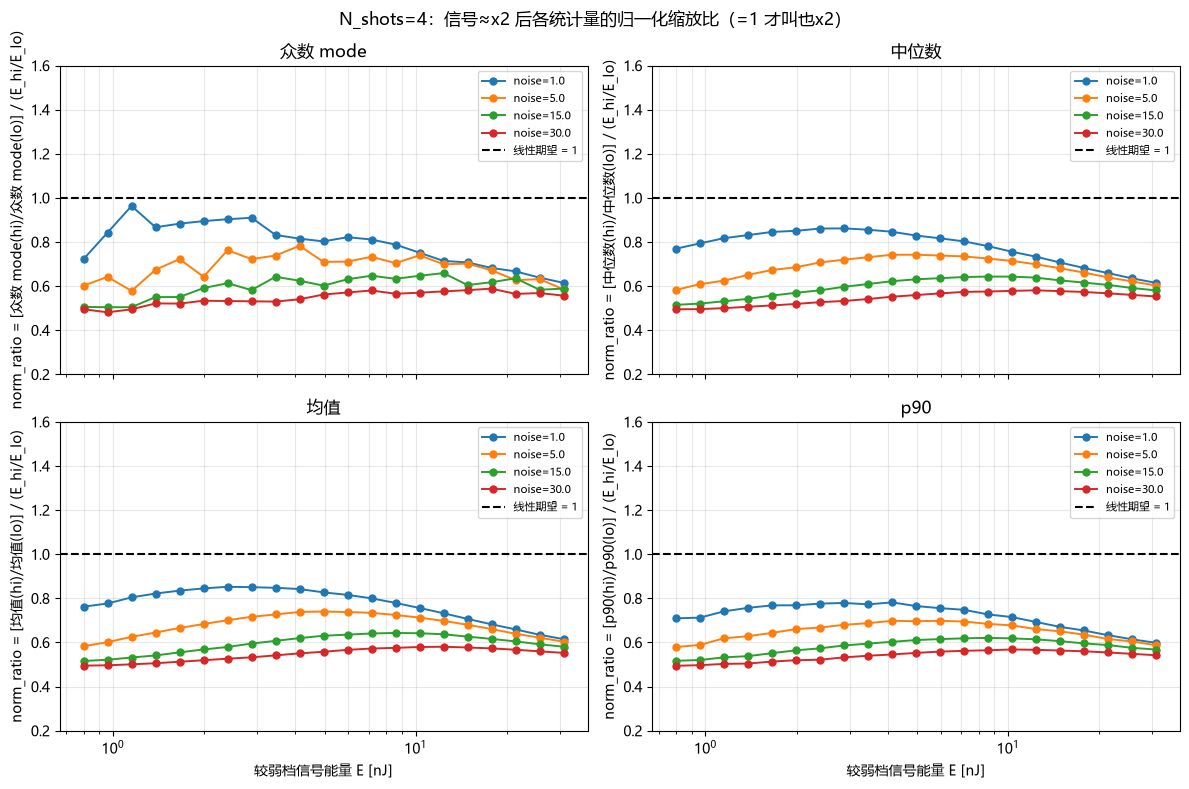

归一化缩放比（=1 为线性；同时列出原始 ratio 与能量倍率）
  N  noise     E_lo     E_hi    E倍率    mode  median    mean     p90 norm_mean
  1    0.5    0.799    1.660   2.08    2.00    1.37    1.33    1.25      0.64
  1    0.5    0.959    1.992   2.08    2.00    1.37    1.36    1.27      0.66
  1    0.5    1.152    2.391   2.08    2.00    1.41    1.41    1.31      0.68
  1    0.5    1.382    2.870   2.08    1.50    1.47    1.45    1.37      0.70
  1    0.5    1.660    3.445   2.08    1.50    1.51    1.49    1.36      0.72
  1    0.5    1.992    4.135   2.08    1.50    1.57    1.54    1.40      0.74
  1    0.5    2.391    4.963   2.08    2.00    1.64    1.59    1.44      0.77
  1    0.5    2.870    5.957   2.08    1.33    1.64    1.62    1.45      0.78
  1    0.5    3.445    7.150   2.08    1.67    1.67    1.63    1.44      0.79
  1    0.5    4.135    8.583   2.08    2.00    1.66    1.62    1.44      0.78
  1    0.5    4.963   10.302   2.08    1.75    1.65    1.62    1.45      0.78
  1    0.5    5.957   12.366  

In [3]:
STAT_KEYS = [("mode", "众数 mode"), ("median", "中位数"),
             ("mean", "均值"), ("p90", "p90")]

for n in N_LIST:
    d, st = DATA[n], STAT[n]
    noises = d["noise"]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    for ax, (key, lab) in zip(axes.ravel(), STAT_KEYS):
        for jn, nt in enumerate(noises):
            xs, ys = [], []
            for i, j in PAIR_IDX:
                a = st[key][i, jn]
                b = st[key][j, jn]
                e_ratio = BOOSTS[j] / BOOSTS[i]
                if a > 0.5:
                    xs.append(E_NJ[i])
                    ys.append((b / a) / e_ratio)
            ax.plot(xs, ys, "o-", ms=5, lw=1.4, label=f"noise={nt:.1f}")
        ax.axhline(1.0, color="k", ls="--", lw=1.5, label="线性期望 = 1")
        ax.set_xscale("log")
        ax.set_ylabel(f"norm_ratio = [{lab}(hi)/{lab}(lo)] / (E_hi/E_lo)")
        ax.set_title(lab)
        ax.set_ylim(0.2, 1.6)
        ax.grid(alpha=0.3, which="both")
        ax.legend(fontsize=8)
    axes[1, 0].set_xlabel("较弱档信号能量 E [nJ]")
    axes[1, 1].set_xlabel("较弱档信号能量 E [nJ]")
    fig.suptitle(f"N_shots={n}：信号≈x2 后各统计量的归一化缩放比（=1 才叫也x2）",
                 fontsize=12)
    fig.tight_layout()
    plt.show()

print("=" * 110)
print("归一化缩放比（=1 为线性；同时列出原始 ratio 与能量倍率）")
print(f"{'N':>3}{'noise':>7}{'E_lo':>9}{'E_hi':>9}{'E倍率':>7}"
      f"{'mode':>8}{'median':>8}{'mean':>8}{'p90':>8}"
      f"{'norm_mean':>10}")
for n in N_LIST:
    st = STAT[n]
    for jn, nt in enumerate(DATA[n]["noise"]):
        for i, j in PAIR_IDX:
            er = BOOSTS[j] / BOOSTS[i]
            row = f"{n:>3}{nt:>7.1f}{E_NJ[i]:>9.3f}{E_NJ[j]:>9.3f}{er:>7.2f}"
            raws = []
            for key, _ in STAT_KEYS:
                a, b = st[key][i, jn], st[key][j, jn]
                r = b / a if a > 0.5 else np.nan
                raws.append(r)
                row += f"{r:>8.2f}"
            row += f"{(raws[2]/er if np.isfinite(raws[2]) else np.nan):>10.2f}"
            print(row)

## 模块 3：净信号增量的缩放（扣掉纯噪声本底）

定义净增量

$$\Delta(E) = \langle\text{peak}\rangle(E) - \langle\text{peak}\rangle(E{=}0)$$

检验 $\Delta(E_{\mathrm{hi}})\,/\,\Delta(E_{\mathrm{lo}})$ 再除以能量倍率后是否等于 1。
这比模块 2 更干净：噪声本底已被减去，直接看**信号贡献**是否随能量加倍而加倍。

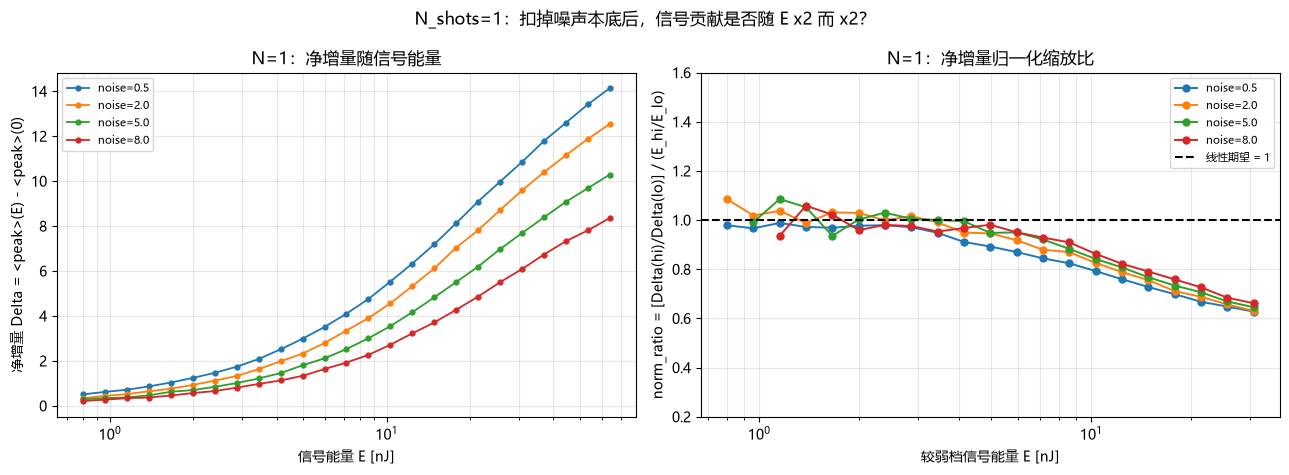

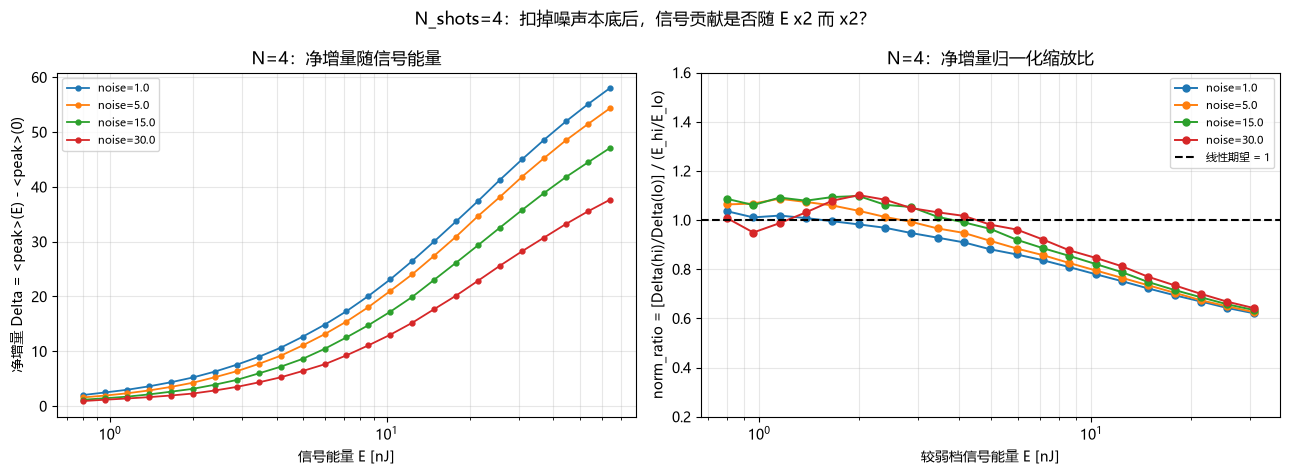

净增量归一化缩放比（=1 为线性）
  N  noise     E_lo     E_hi    E倍率    Δ_lo    Δ_hi    raw比   norm比
  1    0.5    0.799    1.660   2.08    0.51    1.04    2.03    0.98
  1    0.5    0.959    1.992   2.08    0.62    1.24    2.01    0.97
  1    0.5    1.152    2.391   2.08    0.72    1.47    2.05    0.99
  1    0.5    1.382    2.870   2.08    0.86    1.74    2.02    0.97
  1    0.5    1.660    3.445   2.08    1.04    2.08    2.01    0.97
  1    0.5    1.992    4.135   2.08    1.24    2.51    2.03    0.98
  1    0.5    2.391    4.963   2.08    1.47    2.98    2.03    0.98
  1    0.5    2.870    5.957   2.08    1.74    3.51    2.02    0.97
  1    0.5    3.445    7.150   2.08    2.08    4.10    1.97    0.95
  1    0.5    4.135    8.583   2.08    2.51    4.75    1.89    0.91
  1    0.5    4.963   10.302   2.08    2.98    5.53    1.85    0.89
  1    0.5    5.957   12.366   2.08    3.51    6.33    1.81    0.87
  1    0.5    7.150   14.842   2.08    4.10    7.18    1.75    0.84
  1    0.5    8.583   17.816  

In [4]:
for n in N_LIST:
    d, st = DATA[n], STAT[n]
    noises = d["noise"]
    i0 = int(np.argmin(np.abs(BOOSTS - 0.0)))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    ax = axes[0]
    for jn, nt in enumerate(noises):
        delta = st["mean"][:, jn] - st["mean"][i0, jn]
        m = BOOSTS > 0
        ax.plot(E_NJ[m], delta[m], "o-", ms=3.5, lw=1.3, label=f"noise={nt:.1f}")
    ax.set_xscale("log")
    ax.set_xlabel("信号能量 E [nJ]")
    ax.set_ylabel("净增量 Delta = <peak>(E) - <peak>(0)")
    ax.set_title(f"N={n}：净增量随信号能量")
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=8)

    ax = axes[1]
    for jn, nt in enumerate(noises):
        delta = st["mean"][:, jn] - st["mean"][i0, jn]
        xs, ys = [], []
        for i, j in PAIR_IDX:
            if delta[i] > 0.3:
                er = BOOSTS[j] / BOOSTS[i]
                xs.append(E_NJ[i])
                ys.append((delta[j] / delta[i]) / er)
        ax.plot(xs, ys, "o-", ms=5, lw=1.4, label=f"noise={nt:.1f}")
    ax.axhline(1.0, color="k", ls="--", lw=1.5, label="线性期望 = 1")
    ax.set_xscale("log")
    ax.set_xlabel("较弱档信号能量 E [nJ]")
    ax.set_ylabel("norm_ratio = [Delta(hi)/Delta(lo)] / (E_hi/E_lo)")
    ax.set_title(f"N={n}：净增量归一化缩放比")
    ax.set_ylim(0.2, 1.6)
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=8)

    fig.suptitle(f"N_shots={n}：扣掉噪声本底后，信号贡献是否随 E x2 而 x2？",
                 fontsize=12)
    fig.tight_layout()
    plt.show()

print("=" * 110)
print("净增量归一化缩放比（=1 为线性）")
print(f"{'N':>3}{'noise':>7}{'E_lo':>9}{'E_hi':>9}{'E倍率':>7}"
      f"{'Δ_lo':>8}{'Δ_hi':>8}{'raw比':>8}{'norm比':>8}")
for n in N_LIST:
    st = STAT[n]
    i0 = int(np.argmin(np.abs(BOOSTS - 0.0)))
    for jn, nt in enumerate(DATA[n]["noise"]):
        delta = st["mean"][:, jn] - st["mean"][i0, jn]
        for i, j in PAIR_IDX:
            if delta[i] <= 0.3:
                continue
            er = BOOSTS[j] / BOOSTS[i]
            raw = delta[j] / delta[i]
            print(f"{n:>3}{nt:>7.1f}{E_NJ[i]:>9.3f}{E_NJ[j]:>9.3f}{er:>7.2f}"
                  f"{delta[i]:>8.2f}{delta[j]:>8.2f}{raw:>8.2f}{raw/er:>8.2f}")

## 模块 4：PoD 曲线与 PoD50 / PoD90 位置

对每个 noise、每个代表 FAR，画 PoD–能量曲线，标出 **PoD50 / PoD90** 的临界能量。

然后问两件事：
1. PoD50 与 PoD90 的能量比是否接近某个常数？（与「信号×2」无直接关系，但是定位用）
2. **在 PoD50 能量 $E_{50}$ 处把信号加倍到 $2E_{50}$**，peak 统计量是否加倍？
   （用网格上最接近 $E_{50}$ 与 $2E_{50}$ 的点估计）

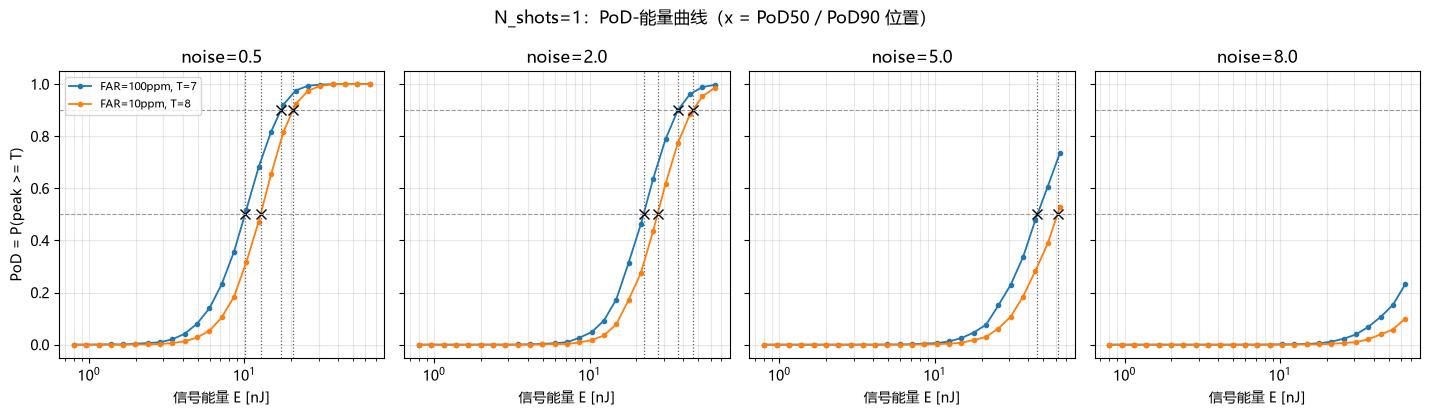

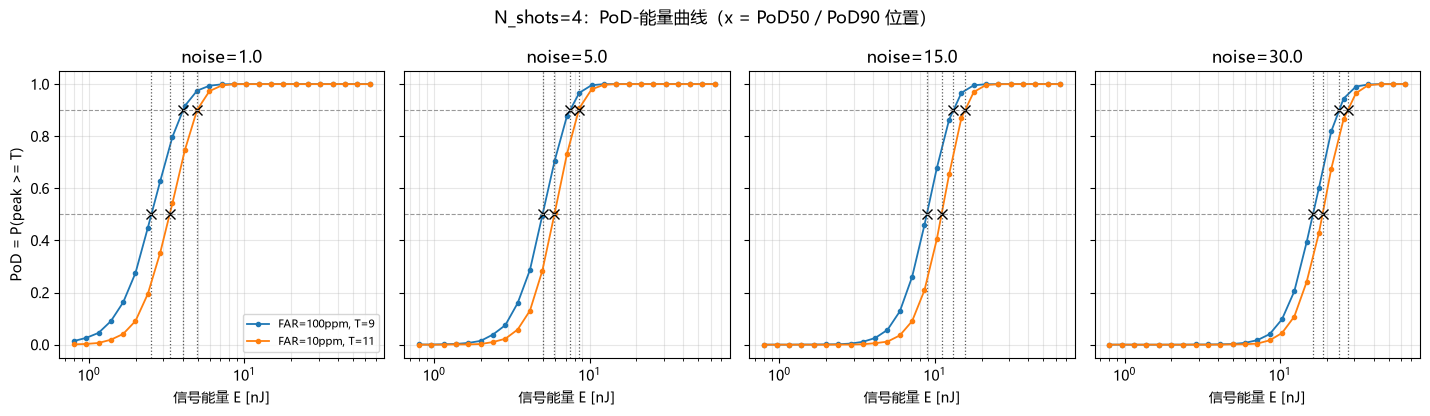

PoD50 / PoD90 临界能量 [nJ]
  N  noise     FAR    T       E50       E90   E90/E50
  1    0.5  100ppm    7    10.086    17.173      1.70
  1    0.5   10ppm    8    12.714    20.547      1.62
  1    2.0  100ppm   12    22.241    36.975      1.66
  1    2.0   10ppm   13    27.360    46.110      1.69
  1    5.0  100ppm   17    45.770       nan       nan
  1    5.0   10ppm   18    61.616       nan       nan
  1    8.0  100ppm   21       nan       nan       nan
  1    8.0   10ppm   22       nan       nan       nan
  4    1.0  100ppm    9     2.521     4.034      1.60
  4    1.0   10ppm   11     3.306     4.959      1.50
  4    5.0  100ppm   19     4.982     7.491      1.50
  4    5.0   10ppm   21     5.939     8.518      1.43
  4   15.0  100ppm   35     8.882    13.191      1.49
  4   15.0   10ppm   38    11.054    15.670      1.42
  4   30.0  100ppm   55    16.298    24.061      1.48
  4   30.0   10ppm   57    18.782    27.346      1.46


In [5]:
POD_LEVELS = [0.50, 0.90]
CRIT = {}   # CRIT[n][jn][far_tag][level] = boost

for n in N_LIST:
    d = DATA[n]
    CRIT[n] = []
    fig, axes = plt.subplots(1, len(d["noise"]),
                             figsize=(3.6 * len(d["noise"]), 4.2),
                             sharey=True, squeeze=False)
    for jn, nt in enumerate(d["noise"]):
        ax = axes[0, jn]
        rec = {}
        for tag in POD_FAR_TAGS:
            ti = FAR_TAGS.index(tag)
            T = int(d["T"][ti, jn])
            pods = np.array([bc_pod(d["cnt"][i, jn], T) for i in range(len(BOOSTS))])
            m = BOOSTS > 0
            ax.semilogx(E_NJ[m], pods[m], "o-", ms=3, lw=1.3,
                        label=f"FAR={tag}, T={T}")
            rec[tag] = {}
            for lv in POD_LEVELS:
                b_c = crossing_boost(BOOSTS, pods, lv)
                rec[tag][lv] = b_c
                if np.isfinite(b_c):
                    ax.axvline(b_c * E_BASE * 1e9, color="0.35", ls=":", lw=0.9)
                    ax.plot([b_c * E_BASE * 1e9], [lv], "kx", ms=7)
        CRIT[n].append(rec)
        ax.axhline(0.5, color="0.6", ls="--", lw=0.8)
        ax.axhline(0.9, color="0.6", ls="--", lw=0.8)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlabel("信号能量 E [nJ]")
        ax.set_title(f"noise={nt:.1f}")
        ax.grid(alpha=0.3, which="both")
        if jn == 0:
            ax.set_ylabel("PoD = P(peak >= T)")
            ax.legend(fontsize=8)
    fig.suptitle(f"N_shots={n}：PoD-能量曲线（x = PoD50 / PoD90 位置）",
                 fontsize=12)
    fig.tight_layout()
    plt.show()

print("=" * 100)
print("PoD50 / PoD90 临界能量 [nJ]")
print(f"{'N':>3}{'noise':>7}{'FAR':>8}{'T':>5}{'E50':>10}{'E90':>10}{'E90/E50':>10}")
for n in N_LIST:
    d = DATA[n]
    for jn, nt in enumerate(d["noise"]):
        for tag in POD_FAR_TAGS:
            ti = FAR_TAGS.index(tag)
            T = int(d["T"][ti, jn])
            e50 = CRIT[n][jn][tag][0.5]
            e90 = CRIT[n][jn][tag][0.9]
            e50n = e50 * E_BASE * 1e9 if np.isfinite(e50) else np.nan
            e90n = e90 * E_BASE * 1e9 if np.isfinite(e90) else np.nan
            ratio = e90n / e50n if (e50n > 0 and np.isfinite(e90n)) else np.nan
            print(f"{n:>3}{nt:>7.1f}{tag:>8}{T:>5}"
                  f"{e50n:>10.3f}{e90n:>10.3f}{ratio:>10.2f}")

## 模块 5：在 PoD50 工作点把信号 ×2，统计量缩放多少？

取 FAR = 100 ppm 的 $E_{50}$，在 boost 网格上找最接近 $E_{50}$ 与 $2E_{50}$ 的两点，
比较 mode / median / mean / p90 的比值，以及净增量比值。

In [6]:
def nearest_boost_idx(target_boost):
    if not np.isfinite(target_boost) or target_boost <= 0:
        return None
    j = int(np.argmin(np.abs(BOOSTS - target_boost)))
    if BOOSTS[j] <= 0:
        return None
    return j


print("=" * 120)
print("在 PoD50(FAR=100ppm) 工作点：E50 → ≈2·E50 的归一化缩放比（=1 为线性）")
print(f"{'N':>3}{'noise':>7}{'E50':>8}{'E≈2E50':>9}{'E倍率':>7}"
      f"{'mode':>8}{'median':>9}{'mean':>8}{'p90':>8}{'Δnorm':>8}")

REF_TAG = "100ppm"
for n in N_LIST:
    d, st = DATA[n], STAT[n]
    i0 = int(np.argmin(np.abs(BOOSTS - 0.0)))
    for jn, nt in enumerate(d["noise"]):
        b50 = CRIT[n][jn][REF_TAG][0.5]
        i = nearest_boost_idx(b50)
        j = nearest_boost_idx(2.0 * b50) if np.isfinite(b50) else None
        if i is None or j is None or j == i:
            print(f"{n:>3}{nt:>7.1f}  （网格上找不到 E50 或 2·E50）")
            continue
        er = BOOSTS[j] / BOOSTS[i]
        norms = []
        for key in ("mode", "median", "mean", "p90"):
            a, b = st[key][i, jn], st[key][j, jn]
            norms.append((b / a) / er if a > 0.5 else np.nan)
        dlo = st["mean"][i, jn] - st["mean"][i0, jn]
        dhi = st["mean"][j, jn] - st["mean"][i0, jn]
        dr = ((dhi / dlo) / er) if dlo > 0.3 else np.nan
        print(f"{n:>3}{nt:>7.1f}{E_NJ[i]:>8.2f}{E_NJ[j]:>9.2f}{er:>7.2f}"
              f"{norms[0]:>8.2f}{norms[1]:>9.2f}{norms[2]:>8.2f}"
              f"{norms[3]:>8.2f}{dr:>8.2f}")

在 PoD50(FAR=100ppm) 工作点：E50 → ≈2·E50 的归一化缩放比（=1 为线性）
  N  noise     E50   E≈2E50    E倍率    mode   median    mean     p90   Δnorm
  1    0.5   10.30    21.39   2.08    0.69     0.75    0.74    0.66    0.79
  1    2.0   21.39    44.39   2.08    0.60     0.62    0.62    0.59    0.69
  1    5.0   44.39    63.96   1.44    0.78     0.75    0.75    0.73    0.79
  1    8.0  （网格上找不到 E50 或 2·E50）
  4    1.0    2.39     4.96   2.08    0.90     0.86    0.85    0.78    0.97
  4    5.0    4.96    10.30   2.08    0.71     0.74    0.74    0.70    0.92
  4   15.0    8.58    17.82   2.08    0.63     0.64    0.64    0.62    0.85
  4   30.0   14.84    30.81   2.08    0.58     0.58    0.58    0.56    0.77


## 结论看板：信号变强时，这些量到底怎么变

下面这张图和这张表就是答案。横轴 = 信号能量 $E$，纵轴 = peak 分布的统计量。
每条曲线对应一个固定噪声档。竖虚线 = 该噪声下 FAR=100ppm 的 **PoD50 / PoD90** 临界能量。

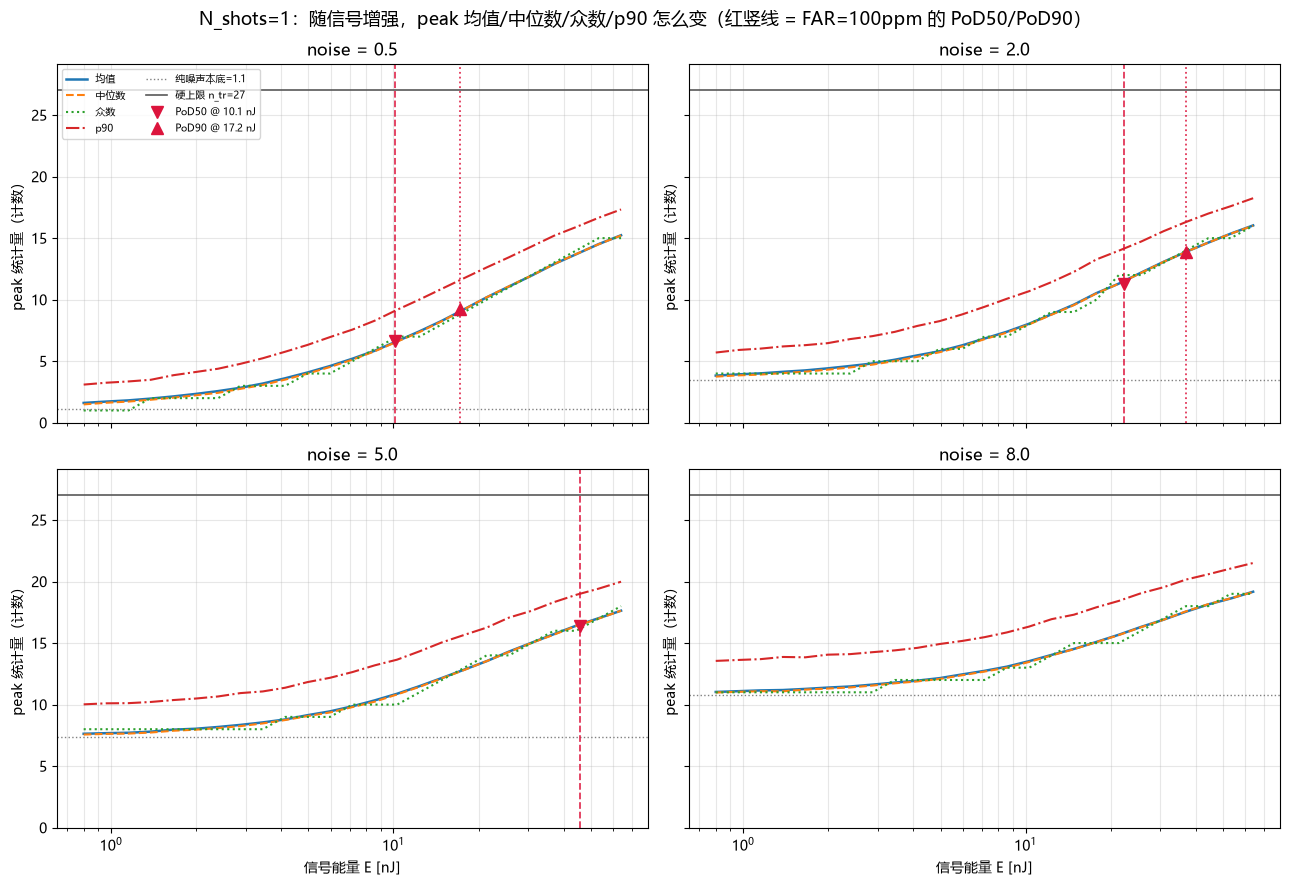

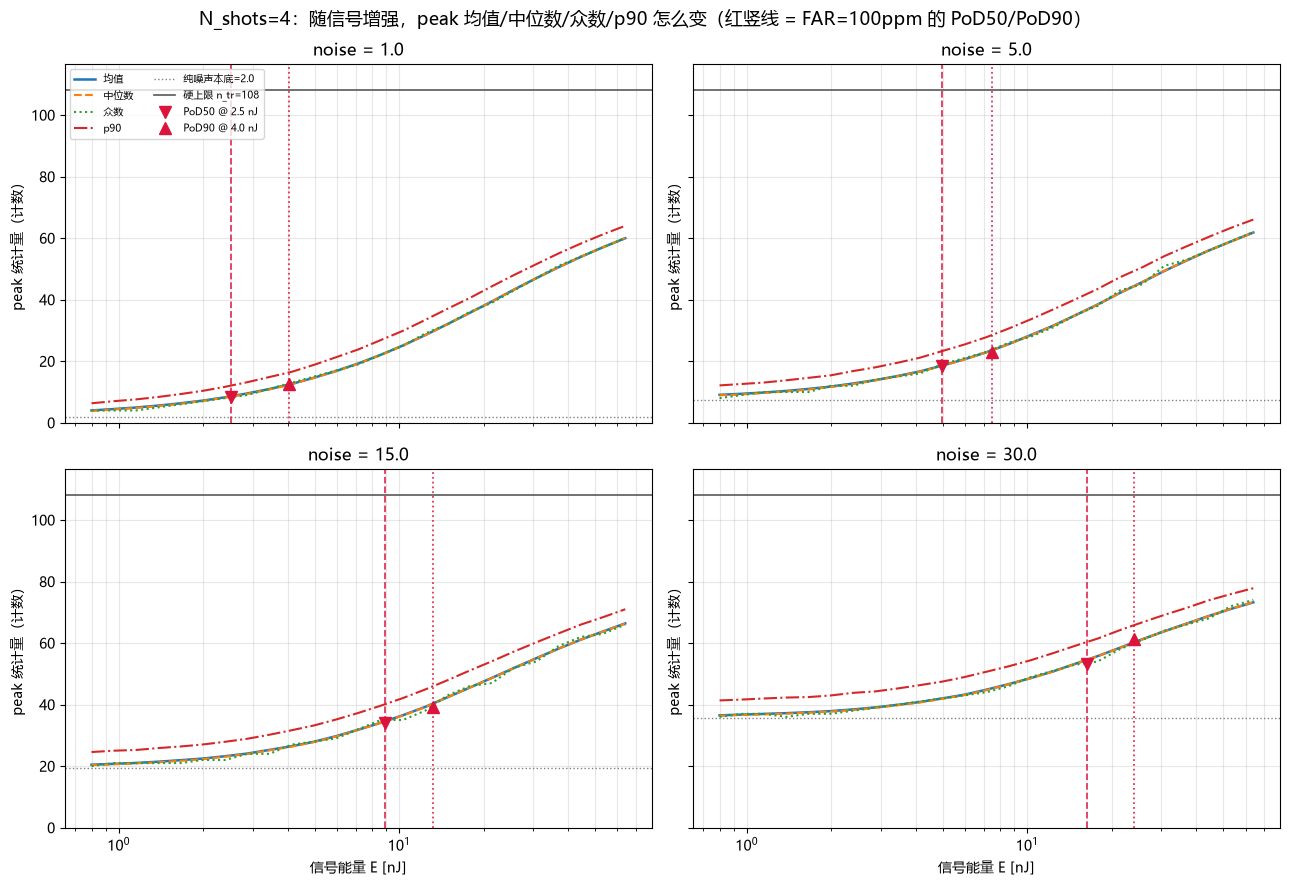

总表：固定噪声下，信号能量升高时各统计量的取值
（单位：peak 计数；Delta = 均值 - 纯噪声本底；PoD@100ppm = 该能量下的检测概率）

### N_shots = 1（硬上限 n_tr = 27）

  noise=0.5  |  阈值 T@100ppm=7  |  纯噪声本底=1.10  |  PoD50=10.1 nJ  PoD90=17.2 nJ
     E[nJ]      众数     中位数      均值     p90   Delta    PoD%
      0.96     1.0     1.6    1.72     3.3    0.62    0.0%
      2.87     3.0     2.8    2.84     4.8    1.74    0.9%
      8.58     6.0     5.8    5.85     8.3    4.75   35.7%
     21.39    10.0    10.2   10.19    12.6    9.09   97.5%
     53.28    15.0    14.5   14.52    16.7   13.41  100.0%

  noise=2.0  |  阈值 T@100ppm=12  |  纯噪声本底=3.49  |  PoD50=22.2 nJ  PoD90=37.0 nJ
     E[nJ]      众数     中位数      均值     p90   Delta    PoD%
      0.96     4.0     3.9    3.93     5.9    0.44    0.0%
      2.87     5.0     4.7    4.82     7.0    1.33    0.0%
      8.58     7.0     7.3    7.39    10.1    3.90    2.6%
     21.39    12.0    11.3   11.30    14.0    7.81   46.2%
     53.28    15.0    15.4   15.37    17.6   11.87   98.9%

  noise=5.0  |  阈值 T@

In [7]:
# ---------- 总图：统计量随信号能量的变化 ----------
STAT_STYLE = [
    ("mean",   "均值",   "-",  1.8),
    ("median", "中位数", "--", 1.5),
    ("mode",   "众数",   ":",  1.5),
    ("p90",    "p90",    "-.", 1.5),
]
NOISE_COLORS = plt.cm.viridis(np.linspace(0.15, 0.85, 4))

for n in N_LIST:
    d, st = DATA[n], STAT[n]
    noises = d["noise"]
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
    axes = axes.ravel()
    m = BOOSTS > 0
    for jn, nt in enumerate(noises):
        ax = axes[jn]
        for key, lab, ls, lw in STAT_STYLE:
            ax.plot(E_NJ[m], st[key][m, jn], ls, lw=lw, color="C0" if key=="mean"
                    else ("C1" if key=="median" else ("C2" if key=="mode" else "C3")),
                    label=lab)
        # 纯噪声本底（E=0 时的均值）水平线
        ax.axhline(st["mean"][0, jn], color="0.5", ls=":", lw=1.0,
                   label=f"纯噪声本底={st['mean'][0, jn]:.1f}")
        ax.axhline(d["n_tr"], color="0.35", lw=1.2, label=f"硬上限 n_tr={d['n_tr']}")
        # PoD50 / PoD90
        for lv, mk, lab2 in [(0.5, "v", "PoD50"), (0.9, "^", "PoD90")]:
            b_c = CRIT[n][jn]["100ppm"][lv]
            if np.isfinite(b_c):
                e_c = b_c * E_BASE * 1e9
                ax.axvline(e_c, color="crimson", ls="--" if lv==0.5 else ":",
                           lw=1.3, alpha=0.85)
                ax.plot([e_c], [st["mean"][nearest_boost_idx(b_c), jn]],
                        mk, color="crimson", ms=8, label=f"{lab2} @ {e_c:.1f} nJ")
        ax.set_xscale("log")
        ax.set_title(f"noise = {nt:.1f}", fontsize=12)
        ax.set_ylabel("peak 统计量（计数）")
        ax.set_ylim(0, d["n_tr"] * 1.08)
        ax.grid(alpha=0.3, which="both")
        if jn >= 2:
            ax.set_xlabel("信号能量 E [nJ]")
        if jn == 0:
            ax.legend(fontsize=7.5, loc="upper left", ncol=2)
    fig.suptitle(f"N_shots={n}：随信号增强，peak 均值/中位数/众数/p90 怎么变"
                 f"（红竖线 = FAR=100ppm 的 PoD50/PoD90）",
                 fontsize=13)
    fig.tight_layout()
    plt.show()


# ---------- 总表：代表性能量点上的数值 ----------
# 每个 N 取 5 个代表性 E（约 1, 3, 8, 20, 50 nJ 附近）
E_TARGETS = [1.0, 3.0, 8.0, 20.0, 50.0]

print("=" * 118)
print("总表：固定噪声下，信号能量升高时各统计量的取值")
print("（单位：peak 计数；Delta = 均值 - 纯噪声本底；PoD@100ppm = 该能量下的检测概率）")
print("=" * 118)

for n in N_LIST:
    d, st = DATA[n], STAT[n]
    ti = FAR_TAGS.index("100ppm")
    print(f"\n### N_shots = {n}（硬上限 n_tr = {d['n_tr']}）")
    for jn, nt in enumerate(d["noise"]):
        T = int(d["T"][ti, jn])
        base = st["mean"][0, jn]
        e50 = CRIT[n][jn]["100ppm"][0.5]
        e90 = CRIT[n][jn]["100ppm"][0.9]
        e50s = f"{e50*E_BASE*1e9:.1f} nJ" if np.isfinite(e50) else "越界"
        e90s = f"{e90*E_BASE*1e9:.1f} nJ" if np.isfinite(e90) else "越界"
        print(f"\n  noise={nt:.1f}  |  阈值 T@100ppm={T}  |  "
              f"纯噪声本底={base:.2f}  |  PoD50={e50s}  PoD90={e90s}")
        print(f"  {'E[nJ]':>8}{'众数':>8}{'中位数':>8}{'均值':>8}{'p90':>8}"
              f"{'Delta':>8}{'PoD%':>8}")
        for et in E_TARGETS:
            i = int(np.argmin(np.abs(E_NJ - et)))
            if BOOSTS[i] <= 0:
                continue
            pod = bc_pod(d["cnt"][i, jn], T) * 100
            delta = st["mean"][i, jn] - base
            print(f"  {E_NJ[i]:>8.2f}{st['mode'][i,jn]:>8.1f}{st['median'][i,jn]:>8.1f}"
                  f"{st['mean'][i,jn]:>8.2f}{st['p90'][i,jn]:>8.1f}"
                  f"{delta:>8.2f}{pod:>7.1f}%")


# ---------- 三句话结论 ----------
print("\n" + "=" * 118)
print("一句话结论")
print("=" * 118)
print('''
1. 随信号能量 E 增大：众数 / 中位数 / 均值 / p90 【全部单调上升】，但【不是直线】——
   先较快，后变慢，逐渐逼近二值硬上限 n_tr（N=1 为 27，N=4 为 108）。

2. 信号加倍时，这些统计量的增幅【小于 x2】（典型只有能量倍率的 60%~80%）；
   扣掉噪声本底后的净增量 Delta，只在弱信号区近似线性，信号一强就饱和。

3. PoD50 / PoD90 是能量轴上的阈值位置（使检测概率达 50%/90%）：
   噪声越大，这两个位置越往右移（需要更强信号才能检出）；
   在 PoD50 工作点再把信号加倍，peak 统计仍然不会加倍。
''')
print("=" * 118)

## 附录：×2 缩放检验与 PoD 细节

前面模块 1–5 是展开分析；日常只看「结论看板」即可。

In [8]:
# ---- 汇总归一化缩放比（线性期望 = 1），作为附录数字 ----
def _collect_norm(use_delta=False):
    out = []
    for n in N_LIST:
        st = STAT[n]
        i0 = int(np.argmin(np.abs(BOOSTS - 0.0)))
        for jn in range(len(DATA[n]["noise"])):
            for i, j in PAIR_IDX:
                er = BOOSTS[j] / BOOSTS[i]
                if use_delta:
                    a = st["mean"][i, jn] - st["mean"][i0, jn]
                    b = st["mean"][j, jn] - st["mean"][i0, jn]
                    if a > 0.3:
                        out.append((b / a) / er)
                else:
                    for key in ("mode", "median", "mean", "p90"):
                        a, b = st[key][i, jn], st[key][j, jn]
                        if a > 0.5:
                            out.append((b / a) / er)
    return np.asarray(out, float)

r_raw = _collect_norm(False)
r_del = _collect_norm(True)
r_pod = []
for n in N_LIST:
    st = STAT[n]
    for jn in range(len(DATA[n]["noise"])):
        b50 = CRIT[n][jn]["100ppm"][0.5]
        i = nearest_boost_idx(b50)
        j = nearest_boost_idx(2.0 * b50) if np.isfinite(b50) else None
        if i is None or j is None or j == i:
            continue
        er = BOOSTS[j] / BOOSTS[i]
        for key in ("mode", "median", "mean", "p90"):
            a, b = st[key][i, jn], st[key][j, jn]
            if a > 0.5:
                r_pod.append((b / a) / er)
r_pod = np.asarray(r_pod, float)

def _summ(arr):
    if len(arr) == 0:
        return "（无有效样本）"
    return (f"中位 {np.median(arr):.2f}，范围 [{arr.min():.2f}, {arr.max():.2f}]")

print("附录数字（norm = [stat(hi)/stat(lo)]/(E_hi/E_lo)，线性=1）")
print(f"  直接统计量：{_summ(r_raw)}")
print(f"  净增量 Delta：{_summ(r_del)}")
print(f"  PoD50 工作点再x2：{_summ(r_pod)}")

附录数字（norm = [stat(hi)/stat(lo)]/(E_hi/E_lo)，线性=1）
  直接统计量：中位 0.60，范围 [0.48, 0.96]
  净增量 Delta：中位 0.93，范围 [0.62, 1.10]
  PoD50 工作点再x2：中位 0.69，范围 [0.56, 0.90]
